In [36]:
import numpy as np
import matplotlib.pyplot as plt


## Questão 1


a) Partindo da equação dada no enunciado:
$$Q_v x = \|x\| e_1$$

Substituindo a definição da matriz refletora $Q_v$:
$$(I - \beta v v^*) x = \|x\| e_1$$

Distribuindo o vetor $x$:
$$x - \beta v v^* x = \|x\| e_1$$

Isolando o termo com o vetor $v$:
$$\beta v v^* x = x - \|x\| e_1$$

Como o produto interno $v^* x$ resulta em um escalar, podemos reorganizar a equação agrupando os termos escalares:
$$[\beta (v^* x)] v = x - \|x\| e_1$$

Temos que $\|x\|e_1$ é o vetor cuja primeira coordenada é a norma de $x$ e o resto é 0. Logo, $x - \|x\|e_1$ é a definição do vetor $v$.

Na construção de refletores de Householder, qualquer múltiplo escalar de $v$ gera a mesma matriz ortogonal $Q_v$, desde que $\beta$ seja ajustado proporcionalmente. Portanto, por conveniência, assumimos que a constante é igual a $1$:
$$[\beta(v^* x)] = 1$$
$$v = x - \|x\| e_1$$

A partir da premissa de que a constante é $1$, vamos isolar o escalar $\beta$:
$$\beta (v^* x) = 1 \implies \beta = \frac{1}{v^* x}$$

Substituindo a expressão encontrada para $v$:
$$\beta = \frac{1}{(x - \|x\| e_1)^* x}$$

Fazendo a distributiva no denominador e sabendo que $x^* x = \|x\|^2$ e $\|x\| e_1^* x = \|x\| x_1$:
$$\beta = \frac{1}{\|x\|^2 - \|x\| x_1}$$

Colocando $\|x\|$ em evidência, chegamos à primeira igualdade do $\beta$:
$$\beta = \frac{1}{\|x\|(\|x\| - x_1)}$$

Para encontrar a segunda igualdade, multiplicamos o numerador e o denominador por $(\|x\| + x_1)$:
$$\beta = \frac{1}{\|x\|(\|x\| - x_1)} \cdot \frac{\|x\| + x_1}{\|x\| + x_1} = \frac{\|x\| + x_1}{\|x\|(\|x\|^2 - x_1^2)}$$

O termo $(\|x\|^2 - x_1^2)$ é a norma ao quadrado do vetor subtraindo o quadrado da sua primeira coordenada. Definindo o vetor $y$ como o restante das coordenadas, $y = (x_2, x_3, \dots, x_n)$, temos a relação de que $\|x\|^2 - x_1^2 = \|y\|^2$. 

Substituindo isso no denominador, chegamos à última igualdade pedida:
$$\beta = \frac{\|x\| + x_1}{\|x\| \cdot \|y\|^2}$$

b) Se tomarmos $x_1$ negativo, em um vetor $x$ tal que $|x_1| \gg |x_n|$ para todo $n \ge 2$, teremos nas fórmulas 2 e 3 um elemento $(\|x\| + x_1)$ no numerador. Além disso, teremos o elemento $(\|x\|^2 - x_1^2)$ no denominador da fórmula 2.

Como $\|x\| \approx |x_1|$ (e sendo $x_1$ negativo, $|x_1| = -x_1$), esses elementos resultarão em valores muito próximos de $0$:
$$\|x\| + x_1 \approx (-x_1) + x_1 = 0$$

Essa subtração de valores quase iguais colabora para a perda severa de precisão devido ao cancelamento catastrófico. 

Porém, na primeira fórmula, temos no denominador o elemento $(\|x\| - x_1)$. Como $x_1$ é negativo, essa operação se torna, na prática, uma soma de magnitudes:
$$\|x\| - x_1 \approx (-x_1) - x_1 = -2x_1$$

Sendo $-2x_1$ um número positivo grande, essa formulação evita a subtração de termos próximos, protegendo o cálculo contra a perda de precisão por causa do cancelamento numérico. Portanto, para $x_1 < 0$, a primeira fórmula é a escolha numérica estável.

In [ ]:
#c)
def reflector(x):
    """
    Calcula o vetor refletor (v) e o escalar (beta) de Householder para um vetor x.
    O refletor Q = I - beta * v * v^T zera todas as componentes de x, exceto a primeira.
    """
    normax = np.linalg.norm(x)

    # Caso extremo: Se o vetor já for nulo, a reflexão não é necessária.
    # Evita divisão por zero nos cálculos de beta a seguir.
    if normax == 0:
        return x, 0.0
        
    # Constrói o vetor w = ||x||*e1 (vetor com a norma de x na 1ª coordenada e 0 nas demais)
    w = np.zeros(x.size)
    w[0] = normax
    
    # Define a direção inicial do vetor refletor (v = x - ||x||*e1)
    v = x - w

    # --- Análise de Estabilidade Numérica ---
    # A escolha da fórmula para o beta depende do sinal da primeira coordenada (x[0])
    # para blindar o algoritmo contra o cancelamento catastrófico.
    if x[0] < 0:
        # Se x[0] é negativo, o termo (||x|| - x[0]) na verdade soma as magnitudes,
        # o que é uma operação segura e sem perda de dígitos significativos.
        beta = 1 / (normax * (normax - x[0]))

    else:
        # Se x[0] é positivo, usamos a fórmula alternativa para o denominador.
        # Aqui, o termo (||x|| + x[0]) no numerador garante uma soma segura.
        y = x[1:] # Fatiamento: isola as coordenadas de x a partir do segundo elemento
        normay = np.linalg.norm(y)
        
        beta = (normax + x[0]) / (normax * (normay**2))

    return v, beta


d) Para encontrar a matriz Jacobiana $J = \frac{\partial v}{\partial x}$, calculamos as derivadas das partes que compõem o vetor $v = x - \|x\|e_1$:

Para o termo da norma:
$$\frac{\partial (e_1 \|x\|)}{\partial x} = e_1 \frac{\partial \|x\|}{\partial x} = e_1 \frac{x^*}{\|x\|} = \frac{e_1 x^*}{\|x\|}$$

Para o termo do próprio vetor $x$:
$$\frac{\partial x}{\partial x} = I$$

Logo, a derivada de $v$ em relação a $x$ é a subtração dessas partes:
$$J = \frac{\partial v}{\partial x} = \frac{\partial x}{\partial x} - \frac{\partial (e_1 \|x\|)}{\partial x} = I - \frac{e_1 x^*}{\|x\|}$$

Sabemos que o número de condicionamento absoluto é dado pela norma da matriz Jacobiana:
$$K_{abs} = \sup \frac{\|\Delta f\|}{\|\Delta x\|} = \|J\|$$

Para deduzir o limite superior desse condicionamento, aplicamos a desigualdade triangular na norma de $J$:
$$\|J\| = \left\| I - \frac{e_1 x^*}{\|x\|} \right\| \le \|I\| + \left\| \frac{e_1 x^*}{\|x\|} \right\|$$

Sabendo que a norma da matriz Identidade é $\|I\| = 1$ e que a norma induzida do produto externo $e_1 x^*$ é o produto das normas dos vetores individuais:
$$\|J\| \le 1 + \frac{\|e_1\| \cdot \|x\|}{\|x\|} = 1 + (\|e_1\| \cdot 1)$$

Como $e_1$ é um vetor unitário, sua norma é $\|e_1\| = 1$. Substituindo na equação:
$$\|J\| \le 1 + 1 = 2$$

Logo, concluímos que o número de condicionamento absoluto é menor ou igual a 2:
$$K_{abs} = \|J\| \le 2$$

## Questão 2 


In [37]:
def apply_reflector(v, beta, b):
    """Função que calcula Qb, onde Q = I - beta * vv* 

    Args:
        v (_type_): vetor que define a transformação de household
        beta (_type_): parâmetro que regula a transformação para manter Q ortogonal
        b (_type_): Vetor que estamos projetando 
    """
    n = len(v)                                          # Atribuição custo 1
    results = b.copy()                                  # Copia custo m = len(b)
    tail = results[-n:]                                 # Copia custo n = len(v)
    results[-n:] = tail - beta * (v.T @ tail) * v       # Produto interno + soma + multiplicação 4n 
    return results                                      # Complexibilidade final Max(m,n)

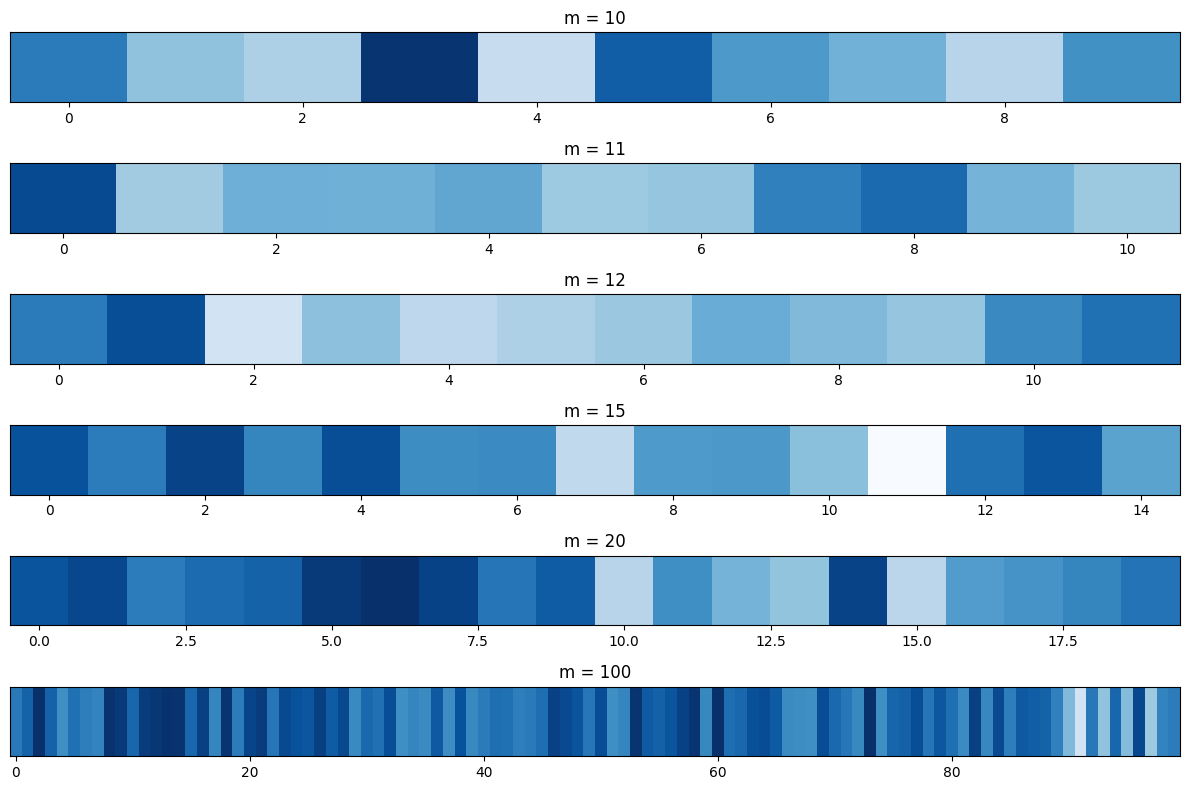

 Os valores do gráfico variam entre -1.6983732490224956 e 0.9841366817461428


In [38]:
n = 10
m_s = [10, 11, 12, 15, 20, 100]
Qbs = []


for m in m_s:
    b = np.random.rand(m)
    v = np.random.rand(n)
    beta = 2 / (v @ v)
    Qb = apply_reflector(v, beta, b)
    Qbs.append(Qb)

vmin = min(np.min(q) for q in Qbs)
vmax = max(np.max(q) for q in Qbs)

fig, ax = plt.subplots(len(m_s), 1, figsize=(12, 8))

for i, (m, Qb) in enumerate(zip(m_s, Qbs)):

    im = ax[i].imshow(Qb.reshape(1, -1), aspect='auto', cmap='Blues', vmin=vmin, vmax=vmax)

    ax[i].set_title(f"m = {m}")
    ax[i].set_yticks([])


plt.tight_layout()
plt.show()

print(f" Os valores do gráfico variam entre {vmin} e {vmax}")
    


Como podemos análisar acima a função deu certo para vetores do mesmo tamanho e maiores que v. Reduzindo os valores do final de b. Aplicando corretamente a reflexão de Householder. 

A aplicação do refletor é realizada sem formar explicitamente a matriz Q. Utilizando a identidade

$$Qb=b−β(vTb)v$$

o custo é dominado por um produto interno e operações vetoriais, resultando em complexidade O(n), onde n é a dimensão do vetor de Householder. A implementação apresentada utiliza uma cópia do vetor de entrada para evitar modificações in-place, o que adiciona um custo O(m), onde m é a dimensão de b. Caso seja permitida a modificação direta do vetor de entrada, a implementação mantém complexidade O(n).